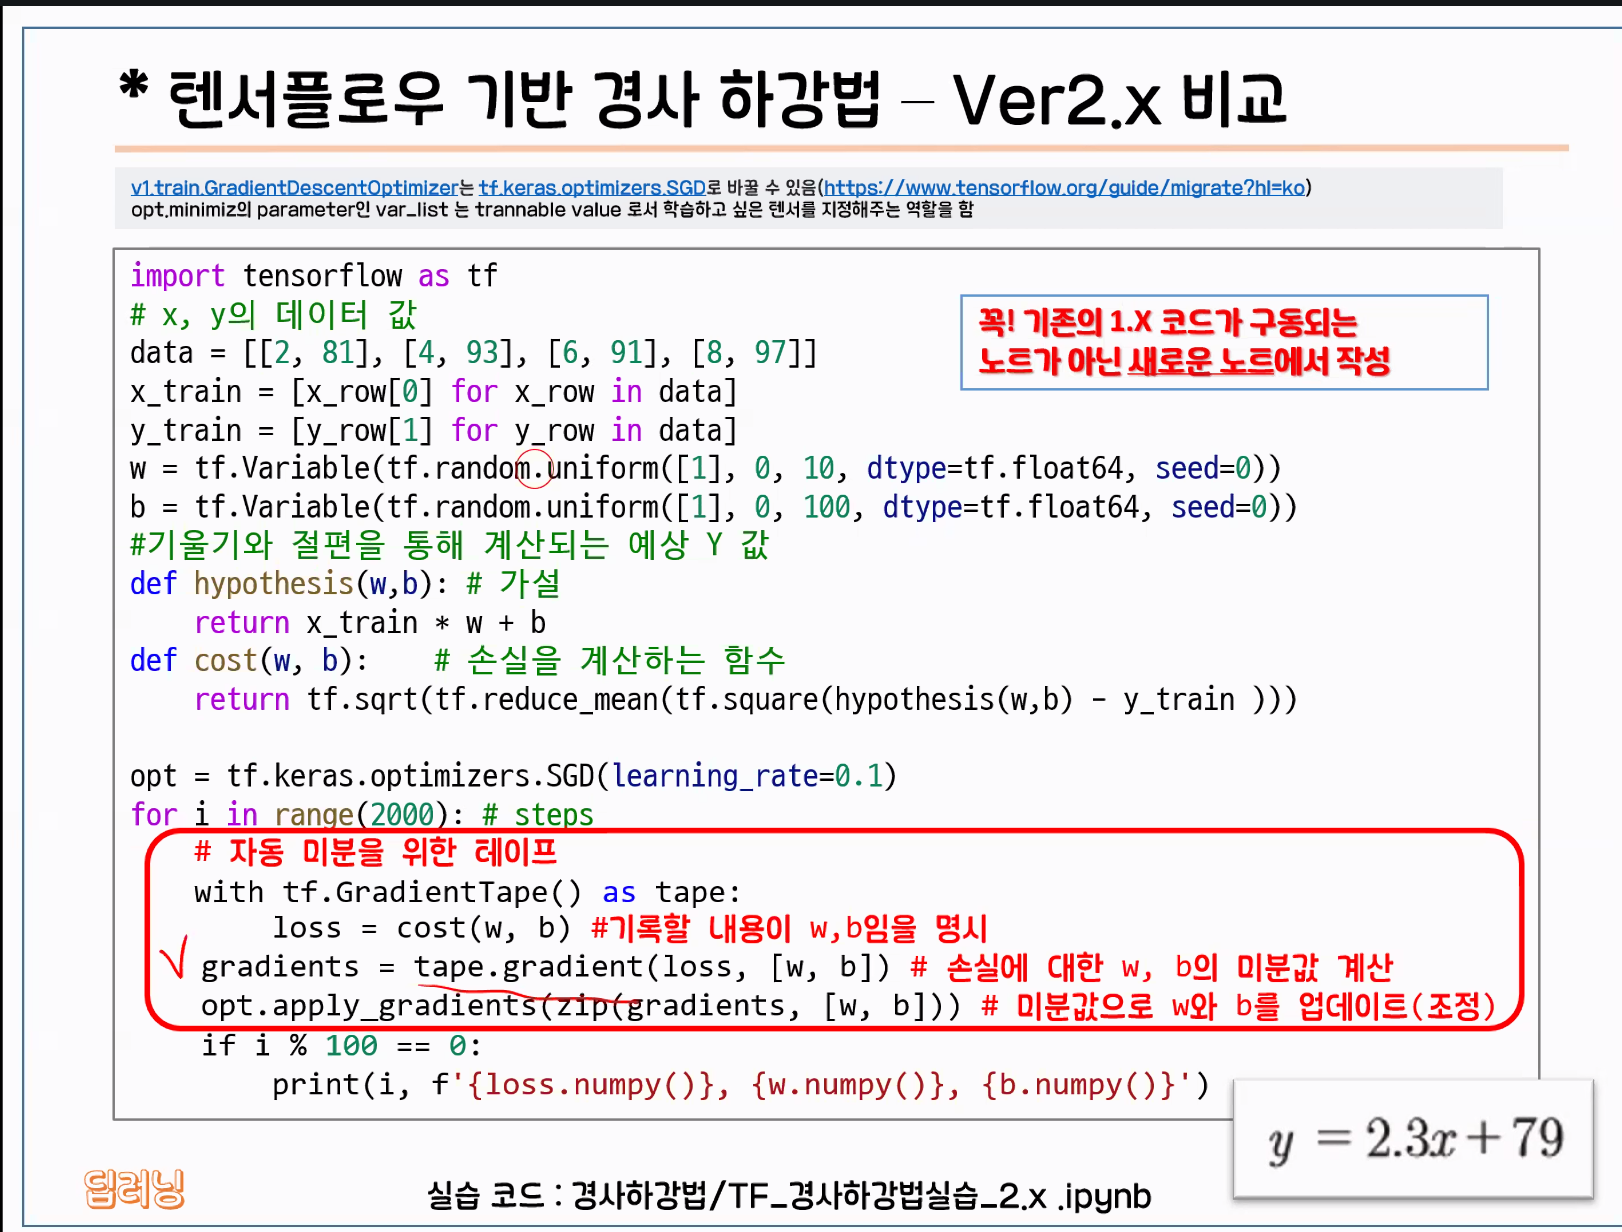

In [ ]:
import tensorflow as tf
# x, y의 데이터 값
data = [[2, 81], [4, 93], [6, 91], [8, 97]]
x_train = [x_row[0] for x_row in data]
y_train = [y_row[1] for y_row in data]

w = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed=0))

# 기울기와 절편을 통해 계산되는 예상 Y 값
def hypothesis(w, b): # 가설
    return x_train * w + b

def cost(w, b): # 손실을 계산하는 함수
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(w, b) - y_train)))

opt = tf.keras.optimizers.SGD(learning_rate=0.1)

for i in range(2000): # steps
    # 자동 미분을 위한 테이프
    with tf.GradientTape() as tape:
        loss = cost(w, b) # 기록할 내용이 w, b임을 명시
    gradients = tape.gradient(loss, [w, b]) # 손실에 대한 w, b의 미분값 계산
    opt.apply_gradients(zip(gradients, [w, b])) # 미분값으로 w와 b를 업데이트(조정)
    
    if i % 100 == 0:
        print(i, f'{loss.numpy()}, {w.numpy()}, {b.numpy()}')

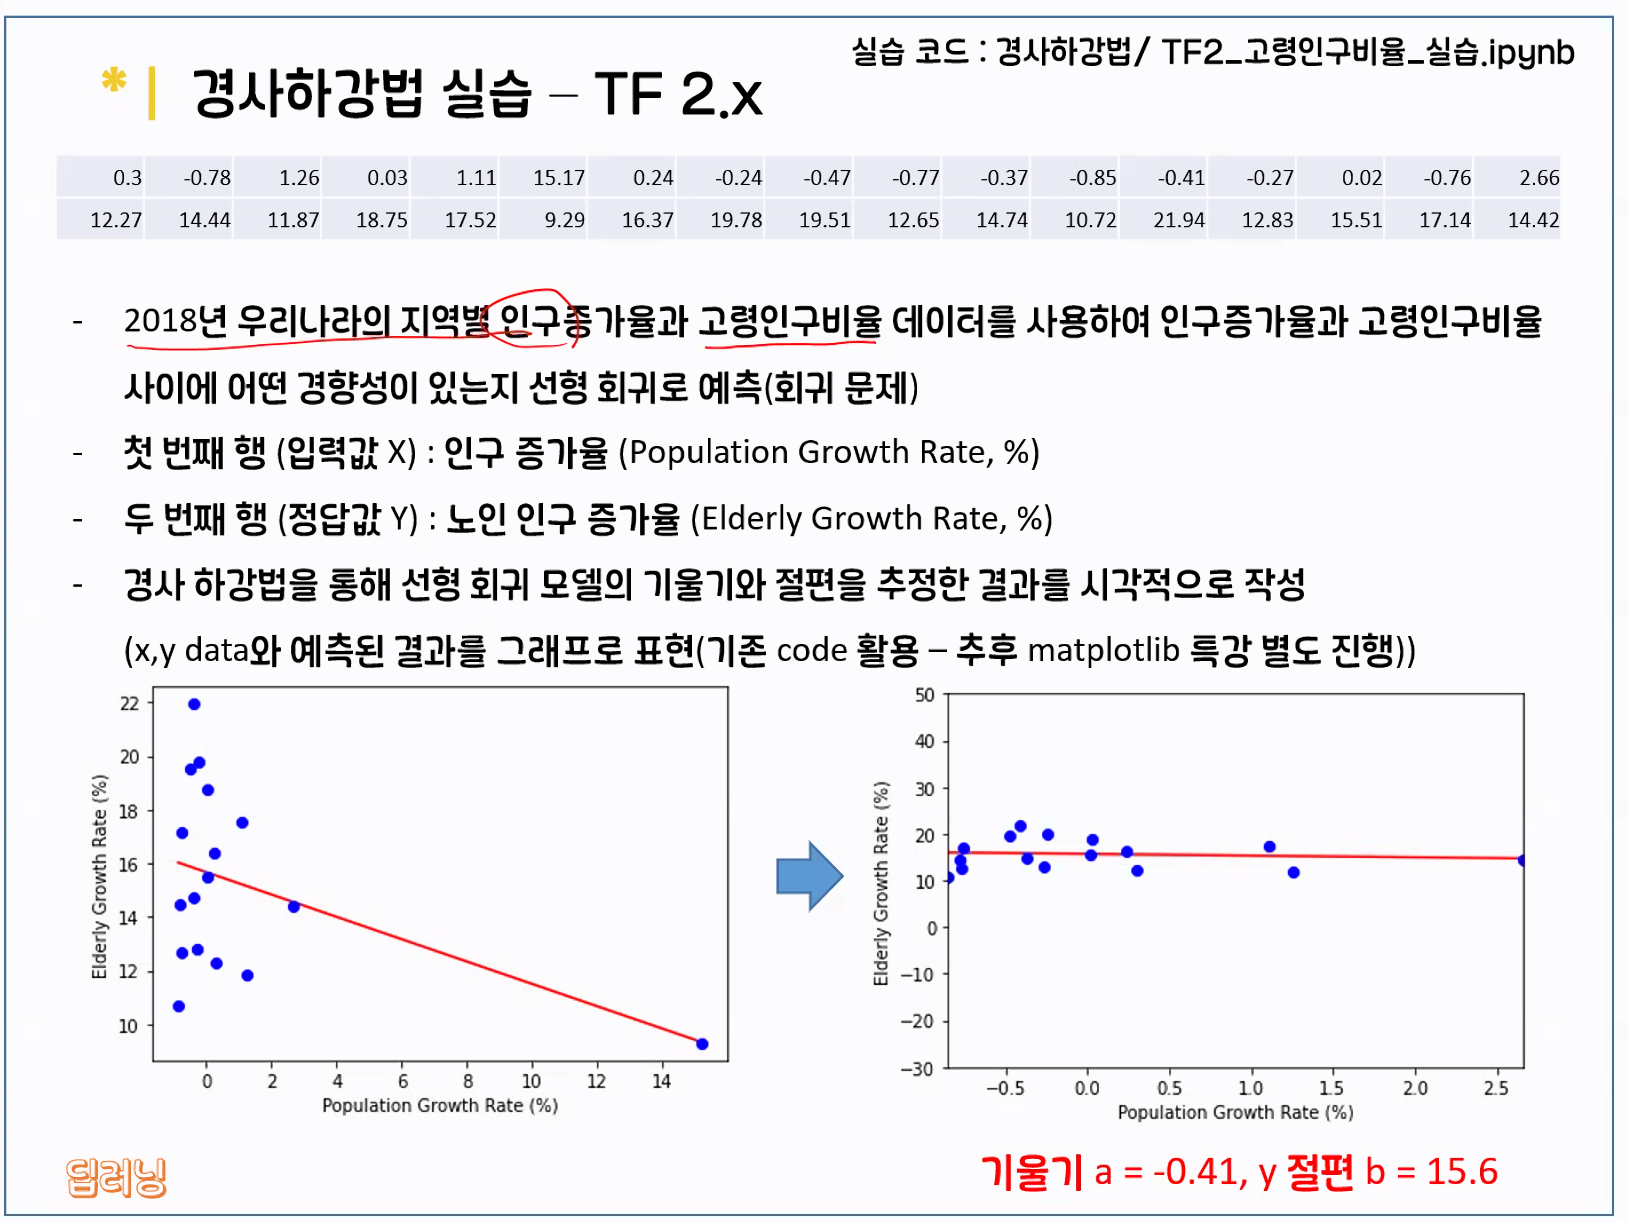

In [ ]:
import tensorflow as tf
import numpy as np

# 시드 고정
tf.random.set_seed(0)
# x, y의 데이터 값
x_data = np.array([0.3, -0.78, 1.26, 0.03, 1.11, 15.17, 0.24, -0.24, -0.47, -0.77,
                   -0.37, -0.85, -0.41, -0.27, 0.02, -0.76, 2.66], dtype=np.float64)
y_data = np.array([12.27, 14.44, 11.87, 18.75, 17.52, 9.29, 16.37, 19.78, 19.51, 
                   12.65, 14.74, 10.72, 21.94, 12.83, 15.51, 17.14, 14.42], dtype=np.float64)

x_train = tf.constant(x_data, dtype=tf.float64)
y_train = tf.constant(y_data, dtype=tf.float64)

w = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed=1))

# 기울기와 절편을 통해 계산되는 예상 Y 값
def hypothesis(w, b): # 가설
    return x_train * w + b

def cost(w, b): # 손실을 계산하는 함수
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(w, b) - y_train)))

opt = tf.keras.optimizers.SGD(learning_rate=0.1)

for i in range(2000): # steps
    # 자동 미분을 위한 테이프
    with tf.GradientTape() as tape:
        loss = cost(w, b) # 기록할 내용이 w, b임을 명시
    gradients = tape.gradient(loss, [w, b]) # 손실에 대한 w, b의 미분값 계산
    opt.apply_gradients(zip(gradients, [w, b])) # 미분값으로 w와 b를 업데이트(조정)
    
    if i % 100 == 0:
        print(i, f'{loss.numpy()}, {w.numpy()}, {b.numpy()}')

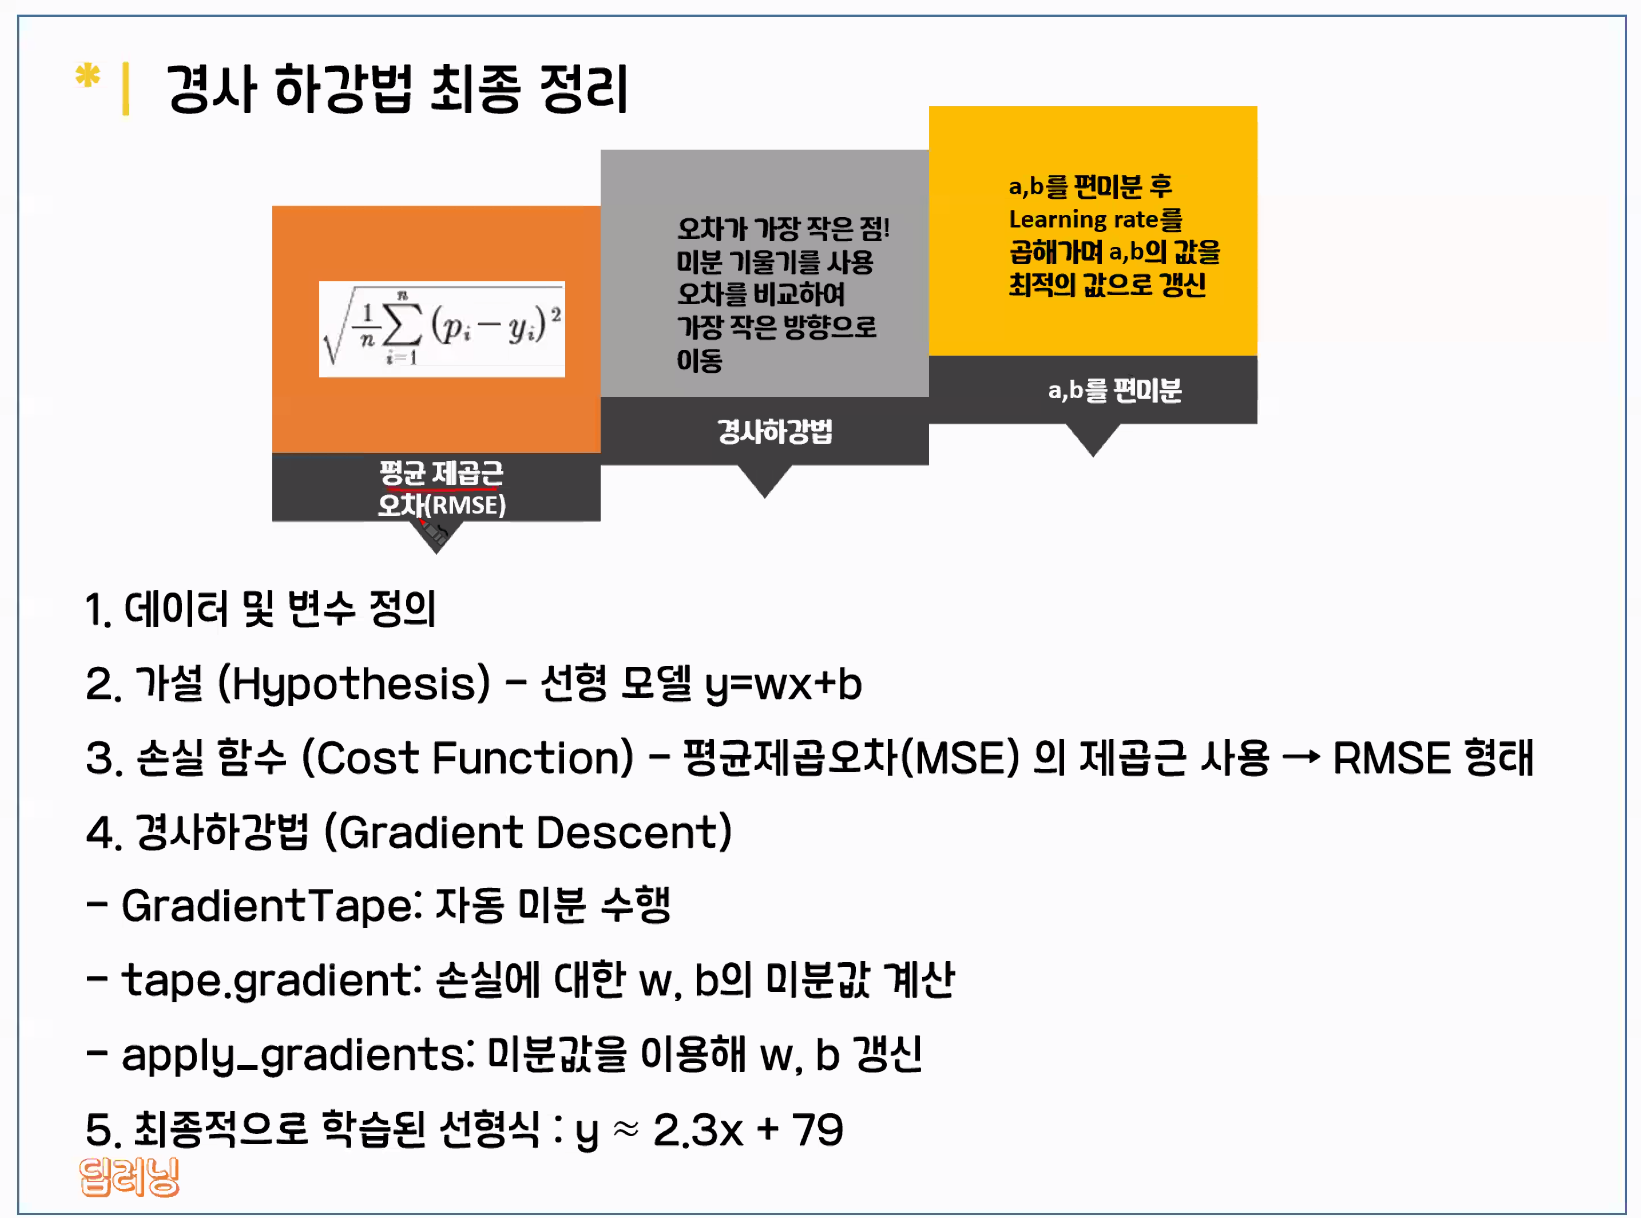

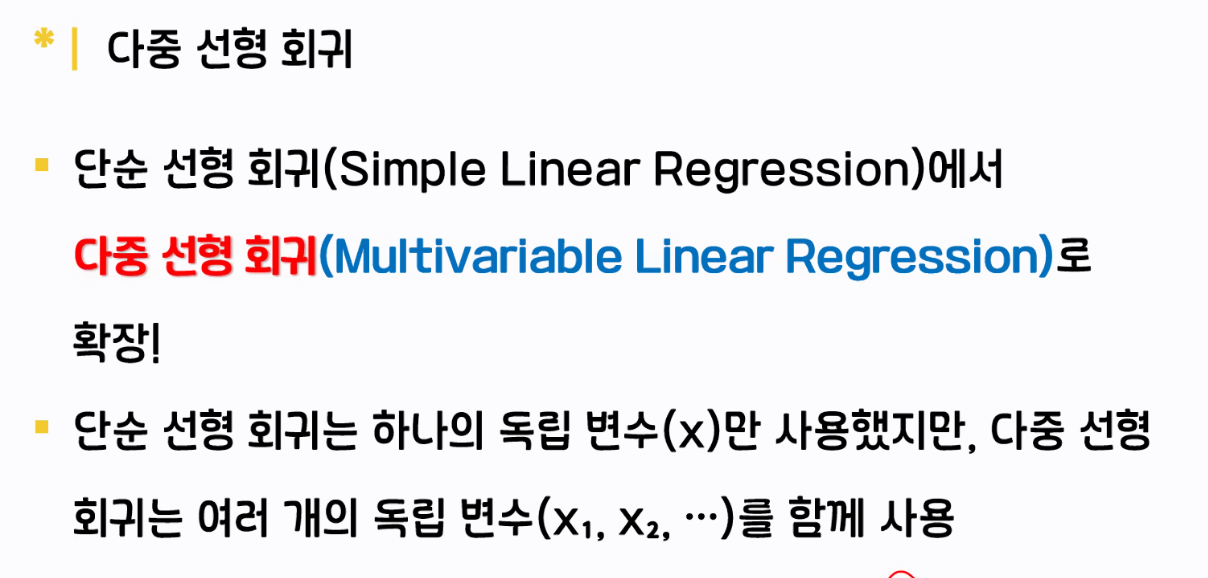

In [ ]:
import tensorflow as tf
import numpy as np

# x, y의 데이터 값
data = [[2, 0, 81], [4, 4, 93], [6, 2, 91], [8, 3, 97]]
x1 = [x_row1[0] for x_row1 in data]
x2 = [x_row2[1] for x_row2 in data] #새로 추가되는 값
y_data = [y_row[2] for y_row in data]

#Variables
a1 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
a2 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed=0))

# 기울기와 절편을 통해 계산되는 예상 Y 값
def hypothesis(a1, a2, b): # 가설
    return x1 * a1 + x2 * a2 + b

def cost(a1, a2, b): # 손실을 계산하는 함수
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(a1, a2, b) - y_data)))

opt = tf.keras.optimizers.SGD(learning_rate=0.1)

for i in range(5000): # steps
    # 자동 미분을 위한 테이프
    with tf.GradientTape() as tape:
        current_cost = cost(a1, a2, b)
    grads = tape.gradient(current_cost, [a1, a2, b]) # 손실에 대한 a1, a2, b의 미분값 계산
    opt.apply_gradients(zip(grads, [a1, a2, b])) # 미분값으로 a1, a2, b를 업데이트(조정)
    
    if i % 100 == 0:
        print(i, f'{current_cost.numpy()}, {a1.numpy()}, {a2.numpy()}, {b.numpy()}')

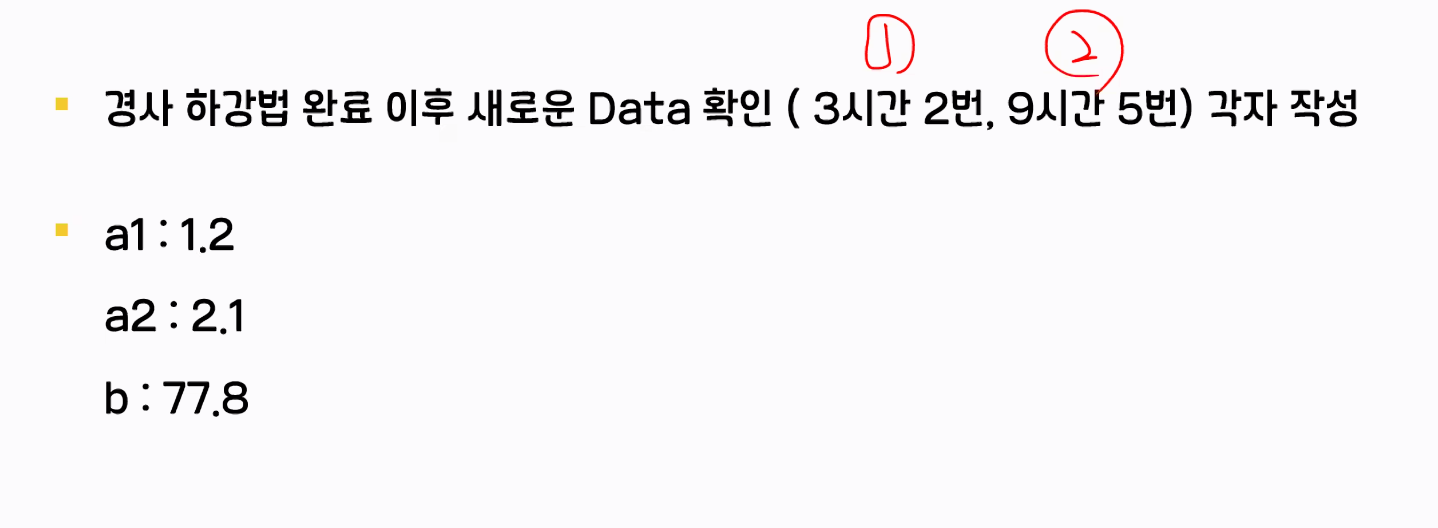

In [14]:
# 학습된 결과값 설정
a1 = 1.2
a2 = 2.1
b = 77.8

# 새로운 데이터 입력 (x1: 시간, x2: 횟수)
new_data = [[3, 2], [9, 5]]

for x in new_data:
    predict = a1 * x[0] + a2 * x[1] + b
    print(f"{x[0]}시간 {x[1]}번일 때 예상 점수: {predict:.2f}")

3시간 2번일 때 예상 점수: 85.60
9시간 5번일 때 예상 점수: 99.10


In [2]:
# -------------------------------------------------------------------------
a1 = 1.2
a2 = 2.1
b = 77.8

# 예측: 3 시간·9 시간 공부했을 때 점수
new_x1 = tf.constant([3.0, 9.0], dtype=tf.float64) # 공부시간
new_x2 = tf.constant([2.0, 5.0], dtype=tf.float64) # 학원횟수

raw_scores = new_x1 * a1 + new_x2 * a2 + b #모델예측
pred_scores = tf.clip_by_value(raw_scores, 0., 100.) #0 ~ 100으로 제한

for hrs, pred in zip(new_x1.numpy(), pred_scores.numpy()):
    print(f"{hrs:.0f}시간 공부 예상 점수 -> {pred:.2f}")

3시간 공부 예상 점수 -> 85.60
9시간 공부 예상 점수 -> 99.10


In [ ]:
## 학습 + 예측

In [ ]:
import tensorflow as tf
import numpy as np

#x, y의 데이터 값
data = [[2, 0, 81], [4, 4, 93], [6, 2, 91], [8, 3, 97]]
x1 = [x_row1[0] for x_row1 in data]
x2 = [x_row2[1] for x_row2 in data]
y_data = [y_row[2] for y_row in data]

#Variables
a1 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
a2 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
b  = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed=0))

#기울기, 절편을 통해 계산되는 y_pred
def hypothesis(a1, a2, b) :
    return a1 * x1 + a2 * x2 + b

#손실 RMSE
def cost(a1, a2, b) :
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(a1, a2, b)-y_data)))

#학습
opt = tf.keras.optimizers.SGD(learning_rate = 0.1)
for i in range(2000) :
    with tf.GradientTape() as tape :
         loss = cost(a1, a2, b)
    gradients = tape.gradient(loss, [a1, a2, b])
    opt.apply_gradients(zip(gradients, [a1, a2, b]))
    if i % 100 == 0 :
       print(i, f'{loss.numpy()}, {a1.numpy()}, {a2.numpy()}, {b.numpy()}')

#예측
new_x1 = tf.constant([3.0, 9.0], dtype=tf.float64) # 공부시간
new_x2 = tf.constant([2.0, 5.0], dtype=tf.float64) # 학원횟수

raw_scores = new_x1 * a1 + new_x2 * a2 + b
pred_scores = tf.clip_by_value(raw_scores, 0., 100.) # 0 ~ 100점

for hrs, cnt, pred in zip(new_x1.numpy(), new_x2.numpy(), pred_scores.numpy()) :
    print(f"{hrs:.0f}시간, 학원 {cnt:.0f}번 공부 예상 점수 {pred:.2f}")

In [ ]:
#단순회귀, 다중회귀 비교

In [3]:
import numpy as np
data = [[2, 0, 81], [4, 4, 93], [6, 2, 91], [8, 3, 97]]
x1 = np.array([x_row1[0] for x_row1 in data], dtype='f')
x2 = np.array([x_row2[0] for x_row2 in data], dtype='f')
y = np.array([y_row[2] for y_row in data], dtype='f')

m_a1 = 1.2301
m_a2 = 2.1633
m_b = 77.8117
m_y2 = m_a1 * x1 + m_a2 *x2 + m_b
print('다중 선형회귀의 점수 평균 :', m_y2.mean())
m_diff_y = abs(y - m_y2)
print('다중 선형회귀의 오차 평균 :', m_diff_y.mean())

s_a1 = 2.3
s_b = 79
s_y1 = s_a1 * x1 + s_b
print('단순 선형회귀의 점수 평균 :', s_y1.mean())
s_diff_y = abs(y - s_y1)
print('단순 선형회귀의 오차 평균 :', s_diff_y.mean())

다중 선형회귀의 점수 평균 : 94.778694
다중 선형회귀의 오차 평균 : 5.08605
단순 선형회귀의 점수 평균 : 90.49999
단순 선형회귀의 오차 평균 : 2.4000015


In [ ]:
## Blood_fat.csv : 혈중지방 파일 실습

In [ ]:
# 연습

In [ ]:
import tensorflow as tf
import numpy as np

#84,46,354
#73,20,190
#65,52,405
#70,30,263
#Blood_fat.csv

#데이터 로드
data = np.loadtxt("Blood_fat.csv", delimiter=",", dtype=np.float64)
x1 = tf.constant(data[:, 0], dtype=tf.float64) # 체중
x2 = tf.constant(data[:, 1], dtype=tf.float64) # 나이
y  = tf.constant(data[:, 2], dtype=tf.float64) # 혈중지방농도

#Variables
a1 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
a2 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
b  = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed=0)) 

#기울기와 절편을 통해 계산되는 예상 Y값
def hypothesis(a1, a2, b): # 가설
    return x1 * a1 + x2 * a2 + b

def cost(a1, a2, b): # 손실을 계산하는 함수
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(a1, a2, b) - y)))

opt = tf.keras.optimizers.SGD(learning_rate=0.001)
for i in range(2000) :
    with tf.GradientTape() as tape :
         loss = cost(a1, a2, b)
    gradients = tape.gradient(loss, [a1, a2, b])
    opt.apply_gradients(zip(gradients, [a1, a2, b]))
    if i % 100 == 0 :
       print(i, f'{loss.numpy()}, {a1.numpy()}, {a2.numpy()}, {b.numpy()}')

#예측
new_x1 = tf.constant(data[20:, 0], dtype=tf.float64) # 체중
new_x2 = tf.constant(data[20:, 1], dtype=tf.float64) # 나이

pred_scores = new_x1 * a1 + new_x2 * a2 + b
# pred_scores = tf.clip_by_value(raw_scores, 0., 100.) # 0 ~ 100점
for wei, orde, pred in zip(new_x1.numpy(), new_x2.numpy(), pred_scores.numpy()) :
    print(f"{wei:.0f}키로, {orde:.0f}살 혈중지방농도 {pred:.2f}")

In [ ]:
# 답지

In [5]:
# 다중 선형 회귀 - 검증 및 그래프 추가
# TensorFlow 2.10 버전용 코드

import tensorflow as tf
import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import mat_kor

# ---------------------------------------------------------
# 1) 데이터 로드
data = np.loadtxt("Blood_fat.csv", delimiter=",", dtype=np.float64)
x1 = tf.constant(data[:, 0], dtype=tf.float64)  # 체중
x2 = tf.constant(data[:, 1], dtype=tf.float64)  # 나이
y  = tf.constant(data[:, 2], dtype=tf.float64)  # 혈중 지방

# ---------------------------------------------------------
# 2) 변수 초기화
a1 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
a2 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
b  = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed=0))

# ---------------------------------------------------------
# 3) 모델·손실 함수
def hypothesis(a1, a2, b):
    return x1 * a1 + x2 * a2 + b

def cost(a1, a2, b):
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(a1, a2, b) - y)))

# ---------------------------------------------------------
# 4) 학습(경사하강법)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
num_epochs = 5000

for i in range(num_epochs):    # steps
    with tf.GradientTape() as tape:
        current_cost = cost(a1, a2, b)
    grads = tape.gradient(current_cost, [a1, a2, b])
    optimizer.apply_gradients(zip(grads, [a1, a2, b]))
    
    if i % 100 == 0:
        print(i, f'{current_cost.numpy()}, {a1.numpy()}, {a2.numpy()}, {b.numpy()}')

# ---------------------------------------------------------
# 5) 학습된 파라미터 확인
print("\n최종 계수")
print("a1 =", a1.numpy())
print("a2 =", a2.numpy())
print("b =", b.numpy())

# ---------------------------------------------------------
# 6) 예측 (예: 첫 25개 샘플)
calc_y = (a1 * x1[:25] + a2 * x2[:25] + b).numpy()
print("\n예측 값(25개):")
print(calc_y)

0 579.8910245142281, [7.99948474], [7.7921178], [18.52939248]
100 45.41474237804826, [1.81858573], [4.38207256], [18.44364284]
200 43.996090811869976, [1.60566912], [4.61357998], [18.44613521]
300 43.41569622961187, [1.48650464], [4.82167379], [18.44964724]
400 43.068077336628924, [1.3943015], [4.98266316], [18.45327794]
500 42.86254819635756, [1.32341485], [5.1064104], [18.45699489]
600 42.74196474969345, [1.26912714], [5.20115769], [18.46077446]
700 42.67152660449445, [1.22764613], [5.27353051], [18.46459961]
800 42.63046825614693, [1.19599181], [5.32873526], [18.46845812]
900 42.606547139625626, [1.17185323], [5.37080936], [18.47234118]
1000 42.59259624729495, [1.15345204], [5.40285978], [18.47624238]
1100 42.58443713062143, [1.13942584], [5.42726675], [18.48015704]
1200 42.57963953739357, [1.1287336], [5.44584902], [18.48408174]
1300 42.57679196219261, [1.12058107], [5.45999423], [18.4880139]
1400 42.575075257392015, [1.11436278], [5.47076019], [18.49195164]
1500 42.574014265606735